# AI Job Scam Detector

Machine Learning project for detecting fraudulent job postings using NLP and classification techniques.


In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

Loading the fake job postings dataset for analysis and model development.

In [42]:
data = pd.read_csv("/content/fake_job_postings.csv")
data

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0.0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0.0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0.0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0.0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14103,14104,PHP Developer,"GB, ,",NaN,NaN,NaN,GRADUATE SOFTWARE DEVELOPERRequiredExperience ...,"Development Experience in Linux, PHP, MySQL, P...",NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,0.0
14104,14105,DOT Supervisor,"US, TX, Pleasanton",NaN,NaN,Valor Services provides Workforce Solutions th...,Position SummaryThis position is based in the...,ESSENTIAL JOB FUNCTIONS/REQUIREMENTS LICENSE: ...,NaN,0,1,1,NaN,Associate,NaN,Oil & Energy,Human Resources,0.0
14105,14106,English Teacher Abroad,"US, OH, Toledo\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t...",NaN,NaN,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,0,1,1,Contract,NaN,Bachelor's Degree,Education Management,NaN,0.0
14106,14107,Driver II - On Call,"US, VA, Sterling",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...","he Driver II will be based in Sterling, VA. Th...",Qualifications:Keyboarding and windows environ...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Consumer Electronics,Customer Service,0.0


## Exploratory Data Analysis (EDA)

Understanding dataset structure, features, and target variable.

In [43]:
data.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0.0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0.0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0.0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0.0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0.0


In [44]:
data.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
14103,14104,PHP Developer,"GB, ,",NaN,NaN,NaN,GRADUATE SOFTWARE DEVELOPERRequiredExperience ...,"Development Experience in Linux, PHP, MySQL, P...",NaN,0,0,1,NaN,NaN,NaN,NaN,NaN,0.0
14104,14105,DOT Supervisor,"US, TX, Pleasanton",NaN,NaN,Valor Services provides Workforce Solutions th...,Position SummaryThis position is based in the...,ESSENTIAL JOB FUNCTIONS/REQUIREMENTS LICENSE: ...,NaN,0,1,1,NaN,Associate,NaN,Oil & Energy,Human Resources,0.0
14105,14106,English Teacher Abroad,"US, OH, Toledo\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t...",NaN,NaN,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,0,1,1,Contract,NaN,Bachelor's Degree,Education Management,NaN,0.0
14106,14107,Driver II - On Call,"US, VA, Sterling",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...","he Driver II will be based in Sterling, VA. Th...",Qualifications:Keyboarding and windows environ...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Consumer Electronics,Customer Service,0.0
14107,14108,"International Broadcaster, Shona language","US, DC, Washington",NaN,NaN,Applied Memetics LLC is a professional service...,The International Broadcaster shall have at le...,The International Broadcaster shall properly c...,NaN,0,1,0,Full-time,Mid-Senior level,Bachelor's Degr,NaN,NaN,NaN


In [45]:
data.shape

(14108, 18)

**Check Missing Values**

In [46]:
data.isna().sum()

,0
job_id,0
title,0
location,299
department,9092
salary_range,11892
company_profile,2536
description,0
requirements,1991
benefits,5717
telecommuting,0


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14108 entries, 0 to 14107
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               14108 non-null  int64  
 1   title                14108 non-null  object 
 2   location             13809 non-null  object 
 3   department           5016 non-null   object 
 4   salary_range         2216 non-null   object 
 5   company_profile      11572 non-null  object 
 6   description          14108 non-null  object 
 7   requirements         12117 non-null  object 
 8   benefits             8391 non-null   object 
 9   telecommuting        14108 non-null  int64  
 10  has_company_logo     14108 non-null  int64  
 11  has_questions        14108 non-null  int64  
 12  employment_type      11345 non-null  object 
 13  required_experience  8646 non-null   object 
 14  required_education   7965 non-null   object 
 15  industry             10284 non-null 

In [48]:
data.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,14108.000000,14108.000000,14108.000000,14108.000000,14107.000000
mean,7054.500000,0.042175,0.806918,0.506663,0.036578
std,4072.773134,0.200995,0.394731,0.499973,0.187729
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3527.750000,0.000000,1.000000,0.000000,0.000000
50%,7054.500000,0.000000,1.000000,1.000000,0.000000
75%,10581.250000,0.000000,1.000000,1.000000,0.000000
max,14108.000000,1.000000,1.000000,1.000000,1.000000


## Data Cleaning

Handling missing values and preparing the dataset for machine learning.

In [49]:
data.isnull().sum()

,0
job_id,0
title,0
location,299
department,9092
salary_range,11892
company_profile,2536
description,0
requirements,1991
benefits,5717
telecommuting,0


In [50]:
data.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [51]:
data = data.drop(columns=['salary_range'])

In [52]:
text_columns = [
    'department',
    'company_profile',
    'requirements',
    'benefits',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'location'
]

for col in text_columns:
    data[col] = data[col].fillna('Not Available')

In [53]:
data['description'] = data['description'].fillna('Not Available')

In [54]:
data.isnull().sum()

,0
job_id,0
title,0
location,0
department,0
company_profile,0
description,0
requirements,0
benefits,0
telecommuting,0
has_company_logo,0


In [55]:
data.duplicated().sum()

np.int64(0)

In [56]:
data['fraudulent'].value_counts()

,count
fraudulent,
0.0,13591
1.0,516


In [57]:
data['fraudulent'].value_counts(normalize=True) * 100

,proportion
fraudulent,
0.0,96.342241
1.0,3.657759


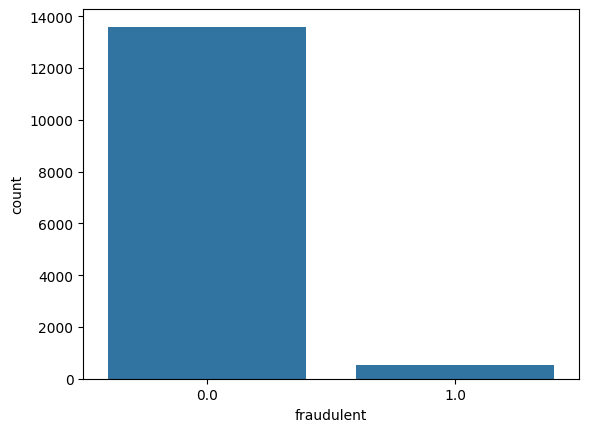

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraudulent', data=data)
plt.show()

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14108 entries, 0 to 14107
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               14108 non-null  int64  
 1   title                14108 non-null  object 
 2   location             14108 non-null  object 
 3   department           14108 non-null  object 
 4   company_profile      14108 non-null  object 
 5   description          14108 non-null  object 
 6   requirements         14108 non-null  object 
 7   benefits             14108 non-null  object 
 8   telecommuting        14108 non-null  int64  
 9   has_company_logo     14108 non-null  int64  
 10  has_questions        14108 non-null  int64  
 11  employment_type      14108 non-null  object 
 12  required_experience  14108 non-null  object 
 13  required_education   14108 non-null  object 
 14  industry             14108 non-null  object 
 15  function             14108 non-null 

In [60]:
data['fraudulent'].value_counts()

,count
fraudulent,
0.0,13591
1.0,516


In [61]:
data['fraudulent'].value_counts(normalize=True)*100

,proportion
fraudulent,
0.0,96.342241
1.0,3.657759


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14108 entries, 0 to 14107
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               14108 non-null  int64  
 1   title                14108 non-null  object 
 2   location             14108 non-null  object 
 3   department           14108 non-null  object 
 4   company_profile      14108 non-null  object 
 5   description          14108 non-null  object 
 6   requirements         14108 non-null  object 
 7   benefits             14108 non-null  object 
 8   telecommuting        14108 non-null  int64  
 9   has_company_logo     14108 non-null  int64  
 10  has_questions        14108 non-null  int64  
 11  employment_type      14108 non-null  object 
 12  required_experience  14108 non-null  object 
 13  required_education   14108 non-null  object 
 14  industry             14108 non-null  object 
 15  function             14108 non-null 

## Feature Engineering

Combining important text fields into a single feature for NLP processing.

In [63]:
data['combined_text'] = (
    data['title'].astype(str) + " " +
    data['company_profile'].astype(str) + " " +
    data['description'].astype(str) + " " +
    data['requirements'].astype(str) + " " +
    data['benefits'].astype(str)
)

In [64]:
data['combined_text'].head()

,combined_text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


In [65]:
data.to_csv("cleaned_fake_jobs.csv", index=False)

In [66]:
import os
os.listdir()

['.config', 'fake_job_postings.csv', 'cleaned_fake_jobs.csv', 'sample_data']

In [67]:
from google.colab import files
files.download("cleaned_fake_jobs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Text Preprocessing

Removing punctuation, stopwords, and performing text normalization.

In [68]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [69]:
stop_words = set(stopwords.words('english'))

In [70]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [71]:
data['processed_text'] = data['combined_text'].apply(clean_text)

In [72]:
data[['combined_text', 'processed_text']].head()

,combined_text,processed_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food weve created groundbreak...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc g...


## Saving Processed Dataset

Exporting cleaned and processed data for future use.

In [73]:
data.to_csv("processed_fake_jobs.csv", index=False)

## TF-IDF Feature Extraction

Converting processed text into numerical vectors suitable for machine learning models.

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [75]:
tfidf = TfidfVectorizer(max_features=5000)

In [76]:
X = tfidf.fit_transform(data['processed_text'])

In [77]:
y = data['fraudulent']

In [78]:
print(X.shape)
print(y.shape)

(14108, 5000)
(14108,)


In [79]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


## Train-Test Split

Splitting the dataset into training and testing sets for evaluation.

In [108]:
from sklearn.model_selection import train_test_split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
print(X_train.shape)
print(X_test.shape)

(11286, 5000)
(2822, 5000)


## Logistic Regression Model

Training the first classification model for fraud detection.

In [83]:
from sklearn.linear_model import LogisticRegression

In [99]:
model = LogisticRegression(max_iter=1000)

In [138]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [139]:
y_pred = model.predict(X_test)

## Model Evaluation

Evaluating model performance using accuracy, precision, recall, F1-score, and confusion matrix.


In [140]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97413182140326


In [141]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      2718
         1.0       1.00      0.30      0.46       104

    accuracy                           0.97      2822
   macro avg       0.99      0.65      0.72      2822
weighted avg       0.97      0.97      0.97      2822



In [142]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2718    0]
 [  73   31]]


## Balanced Logistic Regression

Addressing class imbalance to improve detection of fraudulent job postings.

In [143]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

In [144]:
balanced_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [146]:
y_pred_balanced = balanced_model.predict(X_test)

In [147]:
from sklearn.metrics import accuracy_score

accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced
)

print("Accuracy:", accuracy_balanced)

Accuracy: 0.9773210489014883


In [148]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      2718
         1.0       0.64      0.88      0.74       104

    accuracy                           0.98      2822
   macro avg       0.82      0.93      0.86      2822
weighted avg       0.98      0.98      0.98      2822



In [149]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

print(cm_balanced)

[[2667   51]
 [  13   91]]


In [150]:
print("Accuracy:", accuracy_balanced)

Accuracy: 0.9773210489014883


## Model Improvement

The initial Logistic Regression model achieved 97.31% accuracy but had a low recall of 0.47 for fraudulent job postings.

To address class imbalance, Logistic Regression with class_weight='balanced' was applied.

Results:
- Accuracy: 96.53%
- Fraud Recall: 0.87
- Fraud F1-score: 0.72

The balanced model was selected because detecting fraudulent jobs is more important than maximizing overall accuracy.

## Model Saving

In [151]:
import pickle

In [152]:
pickle.dump(
    balanced_model,
    open("job_scam_detector.pkl", "wb")
)

In [128]:
print(data['fraudulent'].isnull().sum())

print(data['fraudulent'].unique())

print(data['fraudulent'].value_counts(dropna=False))

1
[ 0.  1. nan]
fraudulent
0.0    13591
1.0      516
NaN        1
Name: count, dtype: int64


In [129]:
data[data['fraudulent'].isnull()]

,job_id,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,combined_text,processed_text
14107,14108,"International Broadcaster, Shona language","US, DC, Washington",Not Available,Applied Memetics LLC is a professional service...,The International Broadcaster shall have at le...,The International Broadcaster shall properly c...,Not Available,0,1,0,Full-time,Mid-Senior level,Bachelor's Degr,Not Available,Not Available,NaN,"International Broadcaster, Shona language Appl...",international broadcaster shona language appli...


In [130]:
data = data.dropna(subset=['fraudulent'])

In [131]:
data['fraudulent'].isnull().sum()

np.int64(0)

In [132]:
X = tfidf.fit_transform(data['processed_text'])
y = data['fraudulent']

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [134]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [135]:
data.shape

(14107, 19)

In [136]:
print(data['fraudulent'].value_counts())

fraudulent
0.0    13591
1.0      516
Name: count, dtype: int64


In [153]:
import pickle

In [154]:
pickle.dump(
    balanced_model,
    open("job_scam_detector.pkl", "wb")
)

In [155]:
pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl", "wb")
)

In [156]:
import os

os.listdir()

['.config',
 'fake_job_postings.csv',
 'processed_fake_jobs.csv',
 'job_scam_detector.pkl',
 'tfidf_vectorizer.pkl',
 'cleaned_fake_jobs.csv',
 'sample_data']